In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Superstore : Analyse des ventes

## Objectifs
Analyse des données de ventes et des profits réalisés afin d'en dégager des visions business.

## Dataset
Sample Superstore dataset.

## Outils
Python, Pandas, Matplotlib

## Data loading

In [6]:
df = pd.read_csv("C:/Users/yanno/Documents/ProjetGitHub/SampleSuperstore.csv", encoding="latin1")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Data cleaning

In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## Aperçu du dataset

In [11]:
print(df.head())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

## LES VENTES PAR CATEGORIE

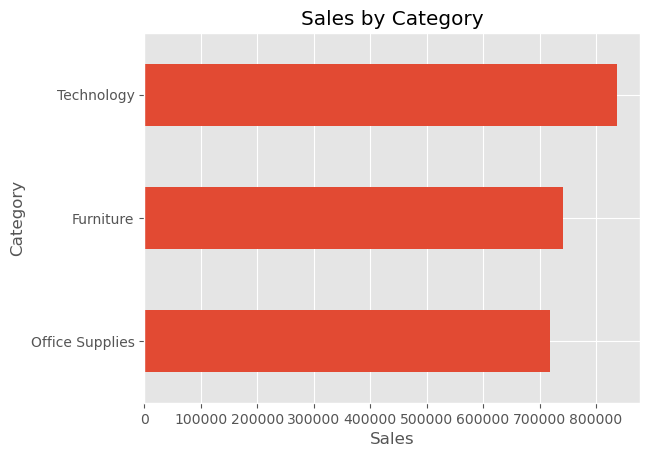

In [19]:
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values()

sales_by_category.plot(kind="barh", title="Sales by Category")
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

Ici, on peut observer qu'on fait le plus de ventes grâce aux technologies, ensuite grâce aux fournitures, puis grâce aux Office Supplies.

Afin de maximiser le nombre de ventes il vaut donc mieux mettre en avant les produits technologiques, ces produits sont les plus prisés, la demande est forte.

## LE PROFIT PAR REGION

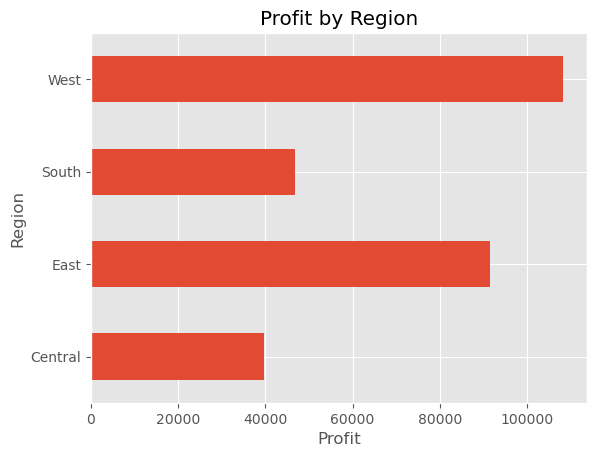

In [21]:
profit_by_region = df.groupby("Region")["Profit"].sum()

profit_by_region.plot(kind="barh", title="Profit by Region")
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.ylabel("Region")
plt.show()

Ici on observe que l'Ouest génère le plus de profit, qu'ils sont supérieurs à 100k $

L'Est arrive à la deuxième place des régions générant le plus de profit avec un profit estimé à peu près à 90k $

Ensuite on a la region Sud un peu en dessous de 50k $ de profit.

Puis à la dernière place on a la région Centre à presque 40k $ de profit.

Il faudrait s'intéresser aux causes de ces résultats afin de pouvoir établir une stratégie solide qui maximise le profit généré dans chaque région.

## LE PROFIT PAR SOUS CATEGORIE

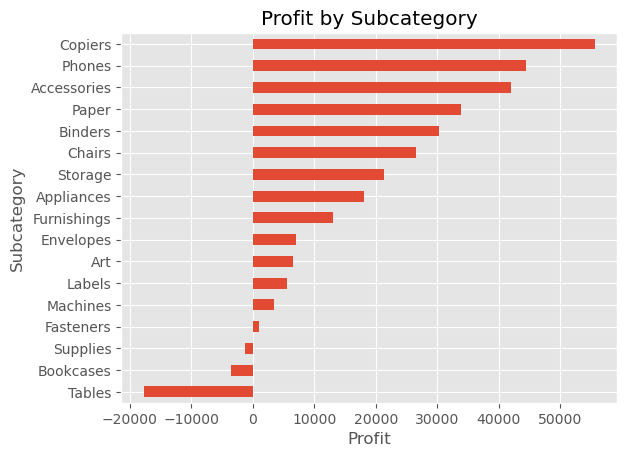

In [22]:
profit_by_subcategory = df.groupby("Sub-Category")["Profit"].sum().sort_values()

profit_by_subcategory.plot(kind="barh", title="Profit by Subcategory")
plt.title("Profit by Subcategory")
plt.xlabel("Profit")
plt.ylabel("Subcategory")
plt.show()

## VISUALISATION DE LA RELATION ENTRE VOLUME DE VENTE D'UN PRODUIT ET PROFIT REALISE

Ce graphique indique clairement quels produits génèrent le plus de profit pour le magasin. Plus le produit est classé haut dans la liste des produits plus il valorise le magasin, à contrario plus le produit est classé bas moins il rend service aux profits du magasin.

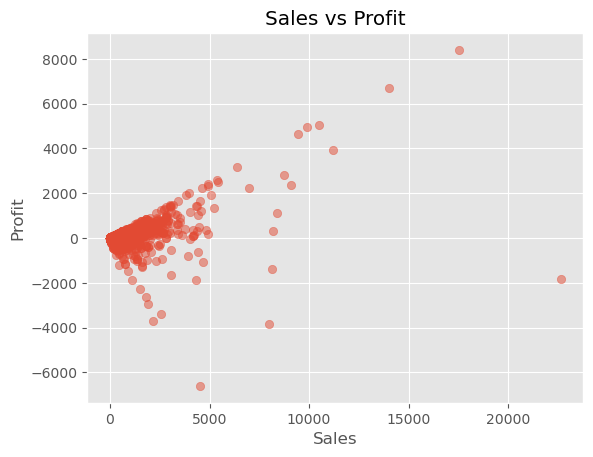

In [23]:
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Key Findings

- Les produits technologiques sont ceux qui génèrent le plus de profit pour le magasin.
- Certains produits génèrent des pertes.
- Le profit réalisé par magasin varie fortement selon la région dans laquelle il est situé.
- Une vente n'est pas toujours synonyme de réalisation de profit.

## Recommendations stratégiques:

OPTION 1 : Se spécialiser dans les produits technologiques car ils sont les plus rentables, et laisser les autres aux oubliettes progressivement en commençant par enlever les produits générants des pertes même si cela réduit la gamme de produit offerte dans les catégories fournitures et office supplies.

OPTION 2 : Trouver de nouveaux fournisseurs pour tous les produits en se concentrant avant tout sur la recherche de nouveaux fournisseurs pour tous les produits générants des pertes aux magasins.